<b><font size="6">Costumer Info Unsupervized Learning</font></b><br><br>
**Authors**: Pedro Ambar, Inês Chainho  
**Date**: April 2026

Unsupervised machine learning plays an important role in customer segmentation by uncovering hidden patterns in data without requiring labeled examples. This notebook walks through customer behavior analysis, identification of relevant customer segments and the development of targeted marketing strategies.

### Project Steps:
1. Environment Setup and EDA
2. Preprocessing and Feature Engineering
3. Exploratory Data Analysis
4. Clustering and Segmentation
5. Cluster Profiling
6. Market Basket Analysis
7. Exporting Results

## Environment Setup and EDA

We begin by importing all necessary libraries and explore and analyze our data.

In [ ]:
import numpy as np
import pandas as pd
import sklearn as skl
import copy
import warnings
warnings.filterwarnings('ignore')
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score,  recall_score, classification_report,  balanced_accuracy_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from matplotlib.colors import ListedColormap
import seaborn as sns 
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import plotly

In [5]:
c_info = pd.read_csv(r"C:\Users\inesb\Downloads\Costumer_Segmentation_april26\customer_info.csv")
c_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377

In [6]:
c_info.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,33038.0,19974.265785,11538.538632,3.000000,9985.250000,19951.500000,29964.750000,40000.000000
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000


In [7]:
c_info.describe(include= "O")

,customer_name,customer_gender,customer_birthdate
count,33038,33038,32873
unique,32543,2,32852
top,Susan Smith,female,03/03/1985 07:32 AM
freq,5,16577,2


In [11]:
obj_cols = ["customer_name", "customer_gender", "customer_birthdate"]
for col in obj_cols:
    print(c_info[col].unique())

['Bsc. Crystal Kitchens' 'Bsc. Glenda Bauman' 'Msc. Antonio Campbell' ...
 'Edna Hasselman' 'George Kramer' 'Sammie Wright']
['female' 'male']
['02/12/1970 01:36 PM' '11/13/1975 06:58 PM' '09/10/1971 10:07 AM' ...
 '05/15/1945 11:09 PM' '05/25/1951 09:02 PM' '07/09/1990 10:27 AM']


## 2. Preprocessing and Feature Engineering

We clean and transform the data:
- Checks for duplicates
- Converts birth date to age
- Removes irrelevant columns
- Fills missing values
- Normalizes numeric data using `StandardScaler` 

In [11]:
clean_df = preprocess_customer_info(customer_info)

## 3. Exploratory Data Analysis

We explore the distributions and relationships of key variables using:
- Boxplots to spot outliers
- Histograms to observe skewed distributions
- Correlation summaries

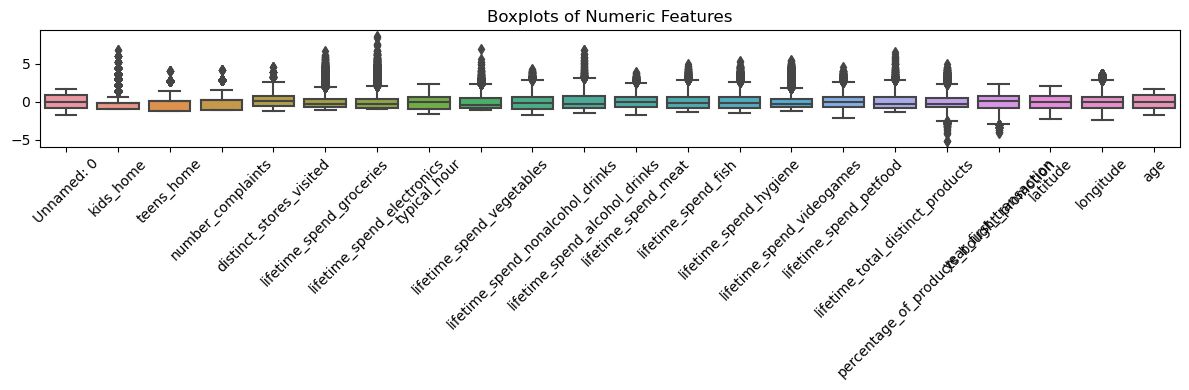

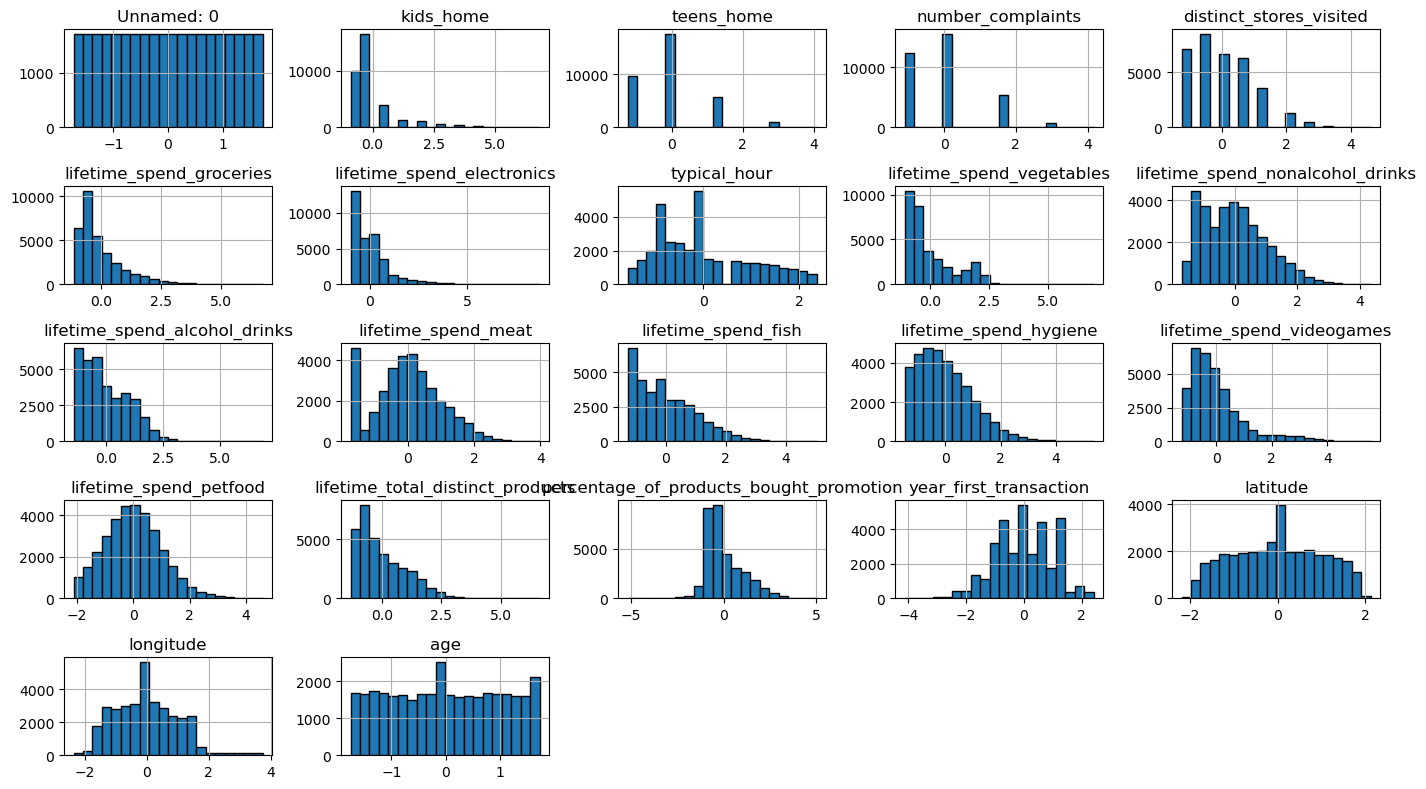

In [12]:
numeric_cols = clean_df.select_dtypes(include='number').columns.drop('customer_id').tolist()
plot_boxplots(clean_df, numeric_cols)
plot_histograms(clean_df, numeric_cols)

## 4. Clustering and Segmentation

We use KMeans clustering to segment customers.  
The optimal number of clusters is chosen using:
- Silhouette Score
- Elbow Method (Inertia)

Cluster labels are added back to the dataset.

k=2, silhouette=0.1528, inertia=627372
k=3, silhouette=0.1627, inertia=569035
k=4, silhouette=0.1297, inertia=539789
k=5, silhouette=0.1325, inertia=502620
k=6, silhouette=0.1031, inertia=498593
k=7, silhouette=0.1233, inertia=464495
k=8, silhouette=0.1464, inertia=439376
k=9, silhouette=0.1494, inertia=430771
k=10, silhouette=0.1432, inertia=422962


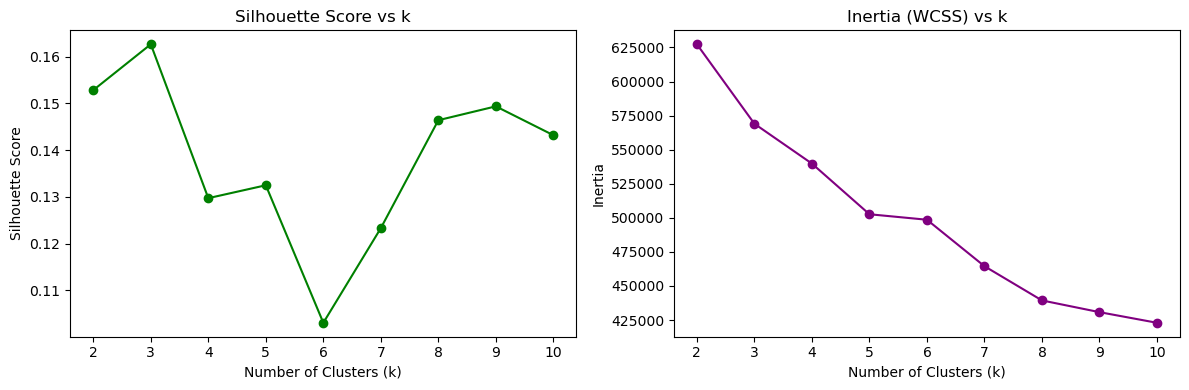

In [13]:
X = clean_df.select_dtypes(include='number').drop(columns=['customer_id'])
k_range, silhouette_scores, inertia_scores = find_optimal_k(X)
plot_kmeans_scores(k_range, silhouette_scores, inertia_scores)

# Best (k = 3)
labels, model = run_kmeans(X, k=3)
clean_df['cluster'] = labels

## 5. Cluster Profiling

To interpret the clusters, we visualize key features across segments using:
- Pairwise plots 
- Boxplots grouped by cluster
- PCA projection for 2D visualization

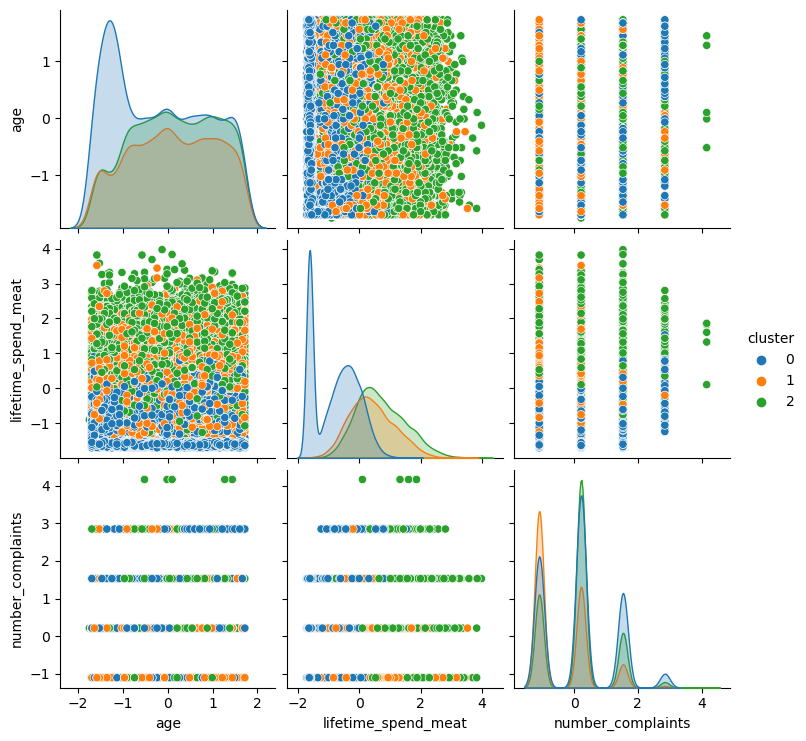

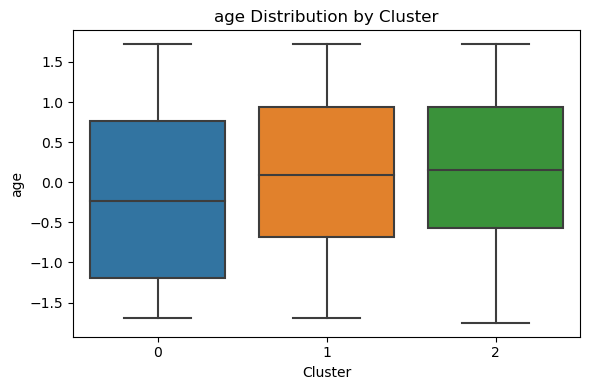

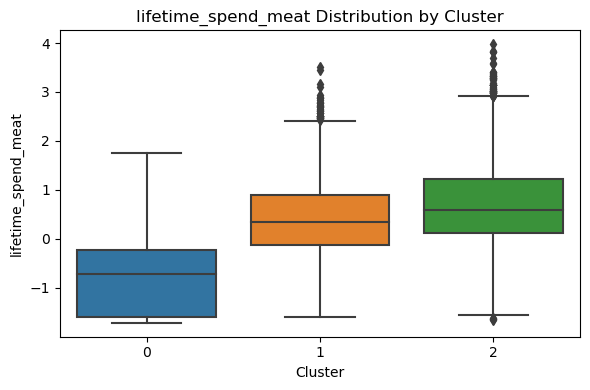

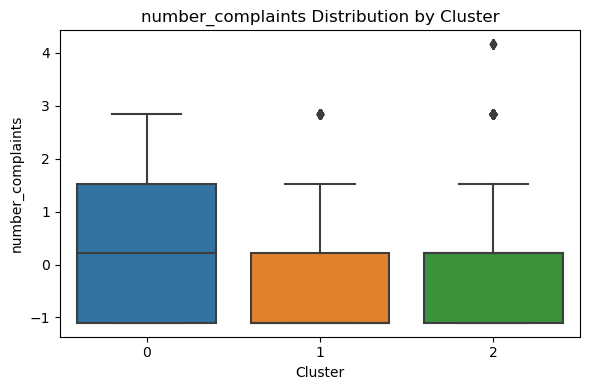

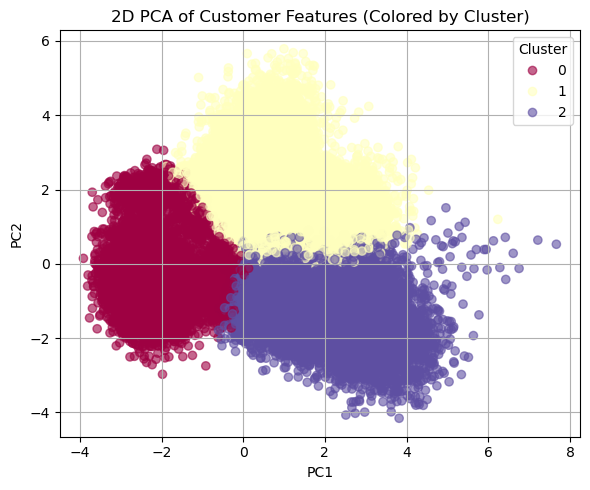

In [14]:
plot_pairwise(clean_df, ['age', 'lifetime_spend_meat', 'number_complaints'])

# Profiling
for feature in ['age', 'lifetime_spend_meat', 'number_complaints']:
    plot_cluster_feature_boxplot(clean_df, feature)
plot_pca_2d(X, labels)

## 6. Exporting Final Cluster Assignments

We export a `.csv` file containing each `customer_id` and their assigned cluster.  
This allows us to link cluster segments with transactional data in the next step.

In [15]:
clean_df[['customer_id', 'cluster']].to_csv("final_clusters.csv", index=False)

## 7. Market Basket Analysis

We perform Market Basket Analysis using the Apriori algorithm.  
This identifies frequent itemsets and association rules from customer purchases.  
By merging basket data with the customer clusters, we can tailor insights to each segment.

--- final_clusters ---
   customer_id  cluster
0        29930        2
1         6813        0
2        39451        2
3        21557        1
4        16415        2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34060 entries, 0 to 34059
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  34060 non-null  int64
 1   cluster      34060 non-null  int64
dtypes: int64(2)
memory usage: 532.3 KB
None
        customer_id       cluster
count  34060.000000  34060.000000
mean   20010.854433      0.896829
std    11557.889072      0.851550
min        1.000000      0.000000
25%    10018.750000      0.000000
50%    19985.500000      1.000000
75%    30042.250000      2.000000
max    40000.000000      2.000000
customer_id    0
cluster        0
dtype: int64
--- costumer_basket ---
   invoice_id                                      list_of_goods  customer_id
0     5062209  ['megaman zero 3', 'energy bar', 'pokemon viol... 

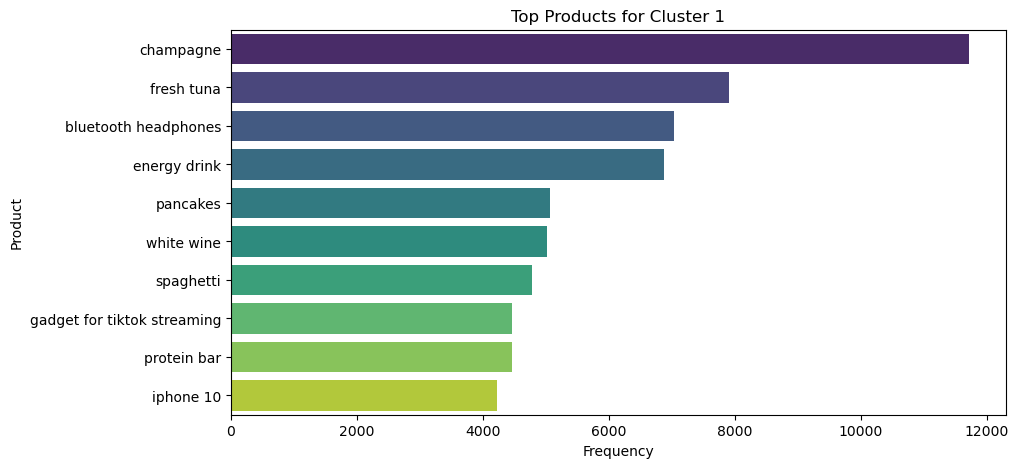

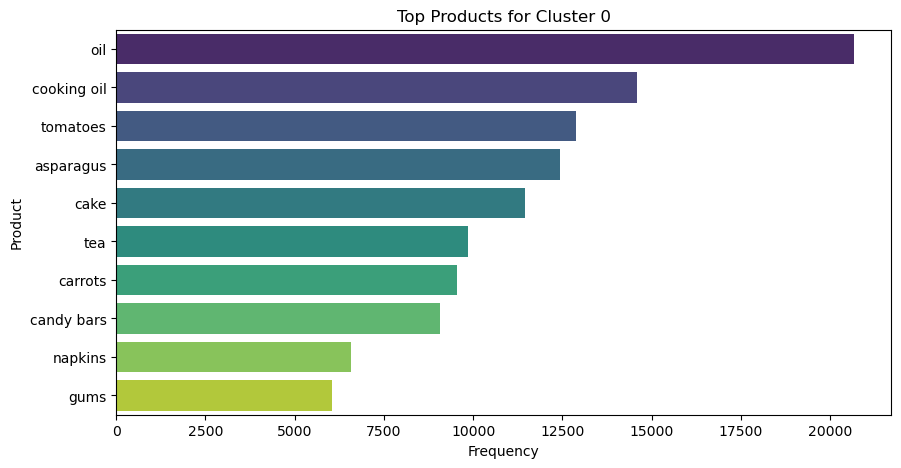

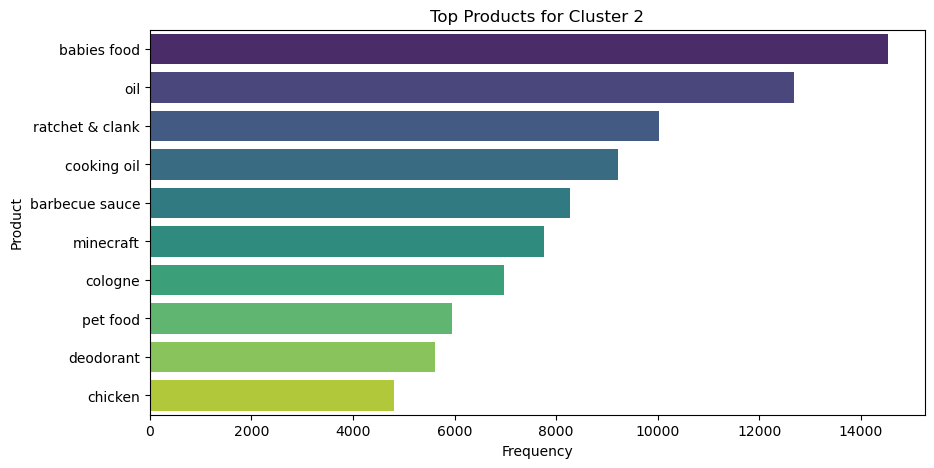


=== Cluster 1 ===
                    antecedents                 consequents   support  \
1705           (cider, bramble)  (white wine, dessert wine)  0.015359   
1822     (red wine, white wine)       (cider, dessert wine)  0.011920   
1465            (beer, bramble)  (white wine, dessert wine)  0.010048   
1482              (cider, beer)  (white wine, dessert wine)  0.020173   
1815       (french wine, cider)  (white wine, dessert wine)  0.012914   
1493          (red wine, cider)          (white wine, beer)  0.010354   
1814  (french wine, white wine)       (cider, dessert wine)  0.012914   
1704      (white wine, bramble)       (cider, dessert wine)  0.015359   
1820          (red wine, cider)  (white wine, dessert wine)  0.011920   
1499        (cider, black beer)  (white wine, dessert wine)  0.010621   

      confidence      lift  
1705    0.424051  5.505507  
1822    0.319018  5.464652  
1465    0.420800  5.463303  
1482    0.418715  5.436237  
1815    0.418317  5.431064  
149

In [16]:
# Load cluster assignments and basket
final_clusters = pd.read_csv("final_clusters.csv")
customer_basket = pd.read_csv("data/customer_basket.csv")

# Inspect the data
inspect_data(final_clusters, name="final_clusters")
inspect_data(customer_basket, name="costumer_basket")

# Merge 
exploded_basket = merge_explode(customer_basket, final_clusters)
inspect_data(exploded_basket, name="exploded_basket")

basket_analysis(exploded_basket)